# Credit Card Fraud Detection Pipeline

### Phase 1 — Exploring and Understanding the Dataset
#### Dataset Download and Initial Setup

In [3]:

# =========================================================
# BLOCK 1 — DATASET DOWNLOAD AND INITIAL SETUP
# =========================================================

# Install Kaggle API
#!pip install kaggle -q

# =========================================================
# IMPORT LIBRARIES
# =========================================================

from dotenv import load_dotenv
import os
import zipfile

# =========================================================
# CONFIGURE KAGGLE API TOKEN
# =========================================================

# Load environment variables

load_dotenv()

# Get Kaggle API token

token = os.getenv("KAGGLE_API_TOKEN")

# Set Kaggle API token

os.environ['KAGGLE_API_TOKEN'] = token

# =========================================================
# DEFINE DATASET
# =========================================================

dataset = "mlg-ulb/creditcardfraud"

# =========================================================
# CREATE DATA DIRECTORIES
# =========================================================

os.makedirs("data/raw", exist_ok=True)

# =========================================================
# DOWNLOAD DATASET FROM KAGGLE
# =========================================================

!kaggle datasets download -d {dataset} -p data/raw

# =========================================================
# EXTRACT ZIP FILE
# =========================================================

zip_path = "data/raw/creditcardfraud.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data/raw")

print("Dataset downloaded and extracted successfully.")

# =========================================================
# DISPLAY AVAILABLE FILES
# =========================================================

os.listdir("data/raw")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and extracted successfully.


['creditcard.csv', 'creditcardfraud.zip']

#### Initial Data Loading and Structural Inspection

In [3]:
# =========================================================
# BLOCK 2 — INITIAL DATA LOADING AND STRUCTURAL INSPECTION
# =========================================================

# Import libraries
import pandas as pd

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("data/raw/creditcard.csv")

# =========================================================
# DATASET DIMENSIONS
# =========================================================

print("Dataset shape:")
print(df.shape)

# =========================================================
# COLUMN NAMES
# =========================================================

print("\nColumn names:")
print(df.columns.tolist())

# =========================================================
# DATA TYPES
# =========================================================

print("\nData types:")
print(df.dtypes)

# =========================================================
# MEMORY USAGE
# =========================================================

memory_usage_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory usage: {memory_usage_mb:.2f} MB")

# =========================================================
# PREVIEW FIRST ROWS
# =========================================================

print("\nFirst 5 rows:")
display(df.head())

# =========================================================
# TARGET VARIABLE INSPECTION
# =========================================================

print("\nTarget variable:")
print(df["Class"].value_counts())

Dataset shape:
(284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Memory usage: 67.36 MB

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Target variable:
Class
0    284315
1       492
Name: count, dtype: int64


#### Data Quality Assessment

In [2]:
# =========================================================
# BLOCK 3 — DATA QUALITY ASSESSMENT
# =========================================================

# Objective:
# Evaluate overall dataset quality before preprocessing
# and model development.
#
# This block focuses on:
# - missing values
# - duplicated rows
# - invalid values
# - sparsity inspection
# - potential cleaning requirements

# =========================================================
# CHECK MISSING VALUES
# =========================================================

# Count missing values per column

missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

# =========================================================
# TOTAL MISSING VALUES
# =========================================================

total_missing = missing_values.sum()

print("\nTotal missing values in dataset:", total_missing)

# =========================================================
# CHECK DUPLICATED ROWS
# =========================================================

duplicate_rows = df.duplicated().sum()

print("\nNumber of duplicated rows:", duplicate_rows)

# =========================================================
# INSPECT UNIQUE VALUES PER COLUMN
# =========================================================

# This helps identify:
# - low-variance columns
# - suspicious constant columns


unique_values = df.nunique()

print("\nUnique values per column:")
print(unique_values)

# =========================================================
# CHECK FOR INFINITE VALUES
# =========================================================

import numpy as np

infinite_values = np.isinf(df).sum()

print("\nInfinite values per column:")
print(infinite_values)

# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

# Useful for identifying:
# - extreme values
# - suspicious ranges

print("\nDataset descriptive statistics:")
display(df.describe())


# =========================================================
# CHECK ZERO VALUES
# =========================================================

# Useful for detecting unusual distributions

zero_counts = (df == 0).sum()

print("\nZero values per column:")
print(zero_counts)




Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values in dataset: 0

Number of duplicated rows: 1081

Unique values per column:
Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Zero values per column:
Time           2
V1             0
V2             0
V3             0
V4             0
V5             0
V6             0
V7             0
V8             0
V9             0
V10            0
V11            0
V12            0
V13            0
V14            0
V15            0
V16            0
V17            0
V18            0
V19            0
V20            0
V21            0
V22            0
V23            0
V24            0
V25            0
V26            0
V27            0
V28            0
Amount      1825
Class     284315
dtype: int64


In [11]:
# =========================================================
# OUTLIER AND DISTRIBUTION INSPECTION
# =========================================================

# Detect extreme ranges using IQR method

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "column": col,
        "outlier_count": len(outliers),
        "outlier_percentage": round((len(outliers) / len(df)) * 100, 4)
    })

outlier_df = pd.DataFrame(outlier_summary)

# Sort by highest number of outliers

outlier_df = outlier_df.sort_values(
    by="outlier_percentage",
    ascending=False
)

print("Outlier summary:")
display(outlier_df)

# =========================================================
# CHECK HIGHLY SKEWED FEATURES
# =========================================================

skewness = df.skew(numeric_only=True)

skewness_df = pd.DataFrame({
    "column": skewness.index,
    "skewness": skewness.values
})

skewness_df["absolute_skewness"] = skewness_df["skewness"].abs()

skewness_df = skewness_df.sort_values(
    by="absolute_skewness",
    ascending=False
)

print("\nFeature skewness summary:")
#print(skewness_df)
display(skewness_df)

Outlier summary:


,column,outlier_count,outlier_percentage
27,V27,39163,13.7507
29,Amount,31904,11.2020
28,V28,30342,10.6535
20,V20,27770,9.7505
8,V8,24134,8.4738
6,V6,22965,8.0634
23,V23,18541,6.5100
12,V12,15348,5.3889
21,V21,14497,5.0901
14,V14,14149,4.9679



Feature skewness summary:


,column,skewness,absolute_skewness
30,Class,23.997579,23.997579
29,Amount,16.977724,16.977724
28,V28,11.192091,11.192091
8,V8,-8.521944,8.521944
23,V23,-5.875140,5.875140
2,V2,-4.624866,4.624866
17,V17,-3.844914,3.844914
21,V21,3.592991,3.592991
1,V1,-3.280667,3.280667
7,V7,2.553907,2.553907


#### Target Variable and Class Imbalance Analysis

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%
Non-fraud percentage: 99.8273%

Imbalance ratio (non-fraud : fraud): 577.88 : 1


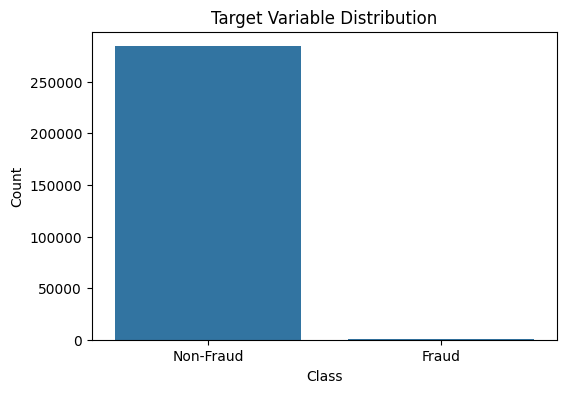

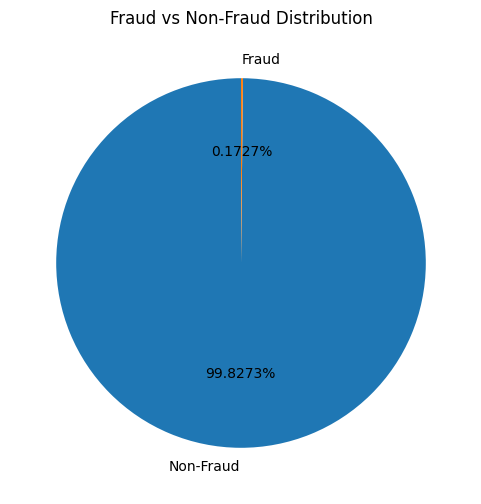

In [3]:
# =========================================================
# BLOCK 4 — TARGET VARIABLE AND CLASS IMBALANCE ANALYSIS
# =========================================================

# Objective: Analyze fraud distribution and evaluate the severity of class imbalance before model development.

#  Install Seaborn
#!pip install seaborn

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# TARGET VARIABLE DISTRIBUTION
# =========================================================

class_counts = df["Class"].value_counts()

print("Class distribution:")
print(class_counts)

# =========================================================
# COMPUTE FRAUD PERCENTAGE
# =========================================================

fraud_percentage = (
    class_counts[1] / len(df)
) * 100

non_fraud_percentage = (
    class_counts[0] / len(df)
) * 100

print(f"\nFraud percentage: {fraud_percentage:.4f}%")
print(f"Non-fraud percentage: {non_fraud_percentage:.4f}%")

# =========================================================
# COMPUTE IMBALANCE RATIO
# =========================================================

imbalance_ratio = (
    class_counts[0] / class_counts[1]
)

print(f"\nImbalance ratio (non-fraud : fraud): "
      f"{imbalance_ratio:.2f} : 1")

# =========================================================
# VISUALIZE TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Target Variable Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.show()

# =========================================================
# VISUALIZE FRAUD PERCENTAGE
# =========================================================

plt.figure(figsize=(6, 6))

plt.pie(
    class_counts,
    labels=["Non-Fraud", "Fraud"],
    autopct='%1.4f%%',
    startangle=90
)

plt.title("Fraud vs Non-Fraud Distribution")

plt.show()




#### Exploratory Data Analysis (EDA)

Amount statistics:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

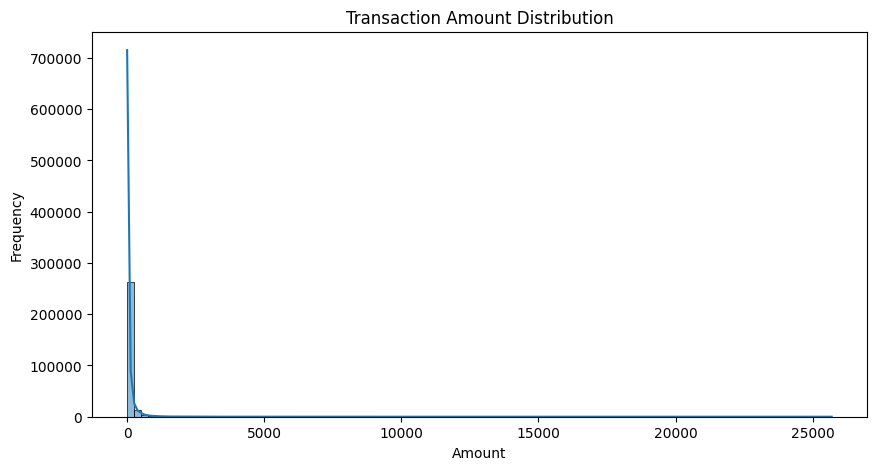

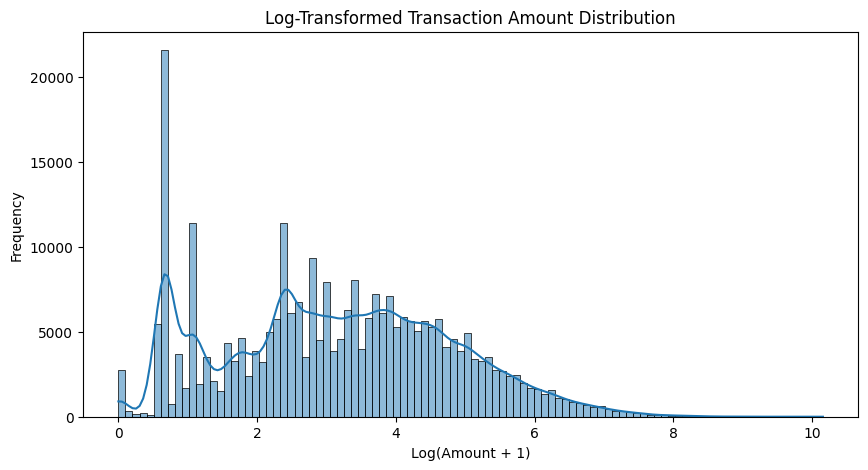

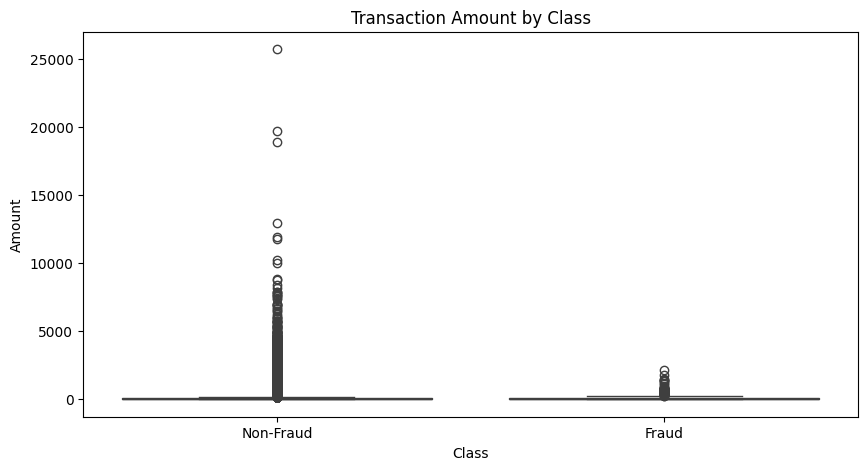

Time statistics:


count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

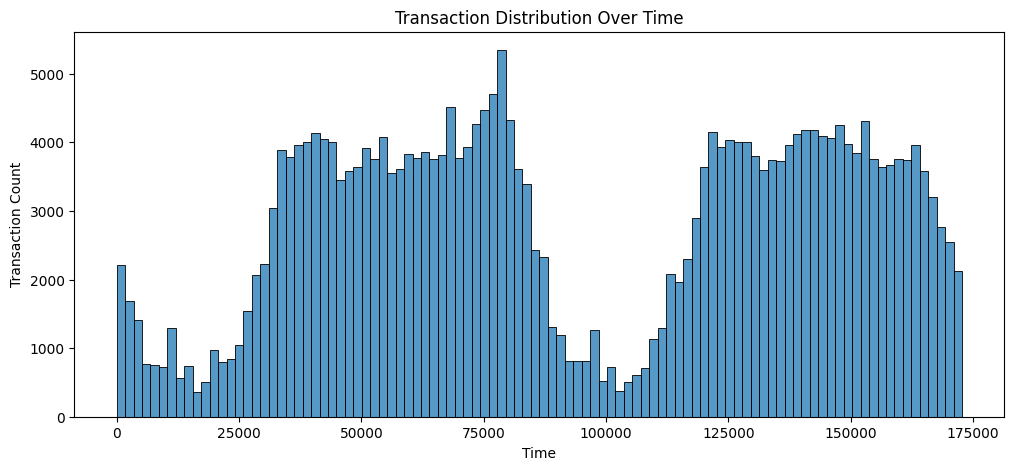

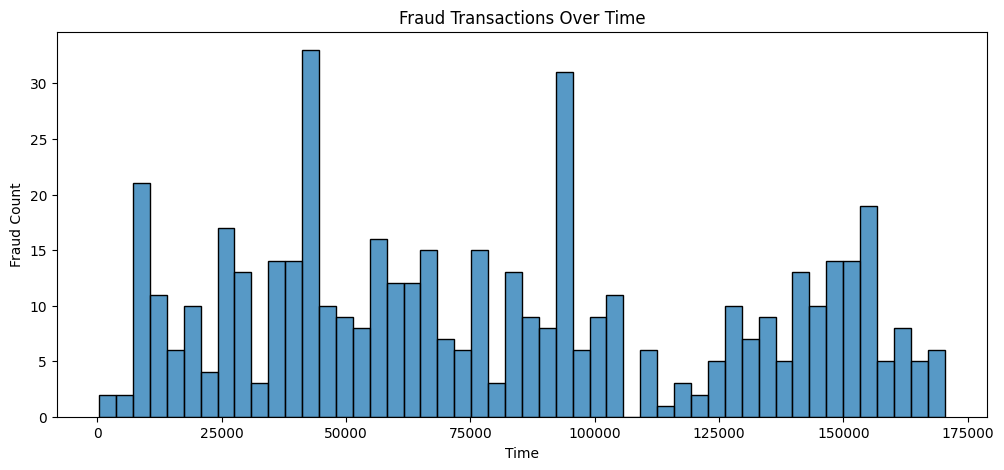

Amount comparison by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Number of zero-amount transactions: 1825

Fraud distribution among zero-amount transactions:
Class
0    1798
1      27
Name: count, dtype: int64

99th percentile Amount threshold: 1017.97
Number of high-value transactions: 2849

Fraud distribution among high-value transactions:
Class
0    2840
1       9
Name: count, dtype: int64

Correlation matrix:


,Time,Amount,Class
Time,1.000000,-0.010596,-0.012323
Amount,-0.010596,1.000000,0.005632
Class,-0.012323,0.005632,1.000000


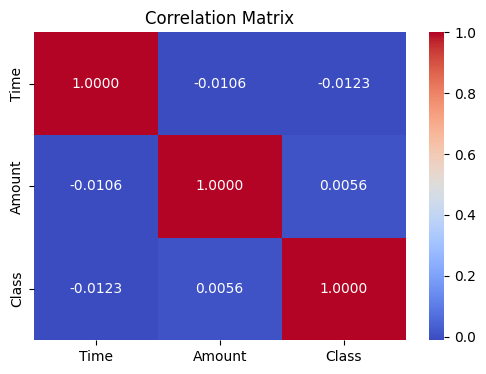


Exploratory Data Analysis Completed.


In [5]:
# =========================================================
# BLOCK 5 — EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# Objective: Perform practical exploratory analysis focused on fraud detection behavior and modeling implications.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# BASIC STATISTICS — AMOUNT
# =========================================================

print("Amount statistics:")
display(df["Amount"].describe())

# =========================================================
# DISTRIBUTION OF TRANSACTION AMOUNTS
# =========================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Amount"],
    bins=100,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# LOG-TRANSFORMED AMOUNT DISTRIBUTION
# =========================================================

# Log transformation helps visualize highly skewed data

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=100,
    kde=True
)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# FRAUD VS NON-FRAUD AMOUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.show()

# =========================================================
# TIME VARIABLE ANALYSIS
# =========================================================

print("Time statistics:")
display(df["Time"].describe())

# =========================================================
# TRANSACTION DISTRIBUTION OVER TIME
# =========================================================

plt.figure(figsize=(12, 5))

sns.histplot(
    df["Time"],
    bins=100,
    kde=False
)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time")
plt.ylabel("Transaction Count")

plt.show()

# =========================================================
# FRAUD DISTRIBUTION OVER TIME
# =========================================================

fraud_df = df[df["Class"] == 1]

plt.figure(figsize=(12, 5))

sns.histplot(
    fraud_df["Time"],
    bins=50,
    kde=False
)

plt.title("Fraud Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Fraud Count")

plt.show()

# =========================================================
# FRAUD VS NON-FRAUD COMPARISON
# =========================================================

comparison_stats = df.groupby("Class")["Amount"].describe()

print("Amount comparison by class:")
display(comparison_stats)

# =========================================================
# ZERO-AMOUNT TRANSACTIONS
# =========================================================

zero_amount_df = df[df["Amount"] == 0]

print(f"Number of zero-amount transactions: "
      f"{len(zero_amount_df)}")

print("\nFraud distribution among zero-amount transactions:")
print(zero_amount_df["Class"].value_counts())

# =========================================================
# HIGH-VALUE TRANSACTIONS
# =========================================================

high_value_threshold = df["Amount"].quantile(0.99)

high_value_df = df[df["Amount"] > high_value_threshold]

print(f"\n99th percentile Amount threshold: "
      f"{high_value_threshold:.2f}")

print(f"Number of high-value transactions: "
      f"{len(high_value_df)}")

print("\nFraud distribution among high-value transactions:")
print(high_value_df["Class"].value_counts())

# =========================================================
# CORRELATION OF AMOUNT AND TIME WITH TARGET
# =========================================================

correlation_subset = df[["Time", "Amount", "Class"]].corr()

print("\nCorrelation matrix:")
display(correlation_subset)

# =========================================================
# HEATMAP VISUALIZATION
# =========================================================

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation_subset,
    annot=True,
    cmap="coolwarm",
    fmt=".4f"
)

plt.title("Correlation Matrix")

plt.show()

# =========================================================
# EDA SUMMARY
# =========================================================

print("\nExploratory Data Analysis Completed.")

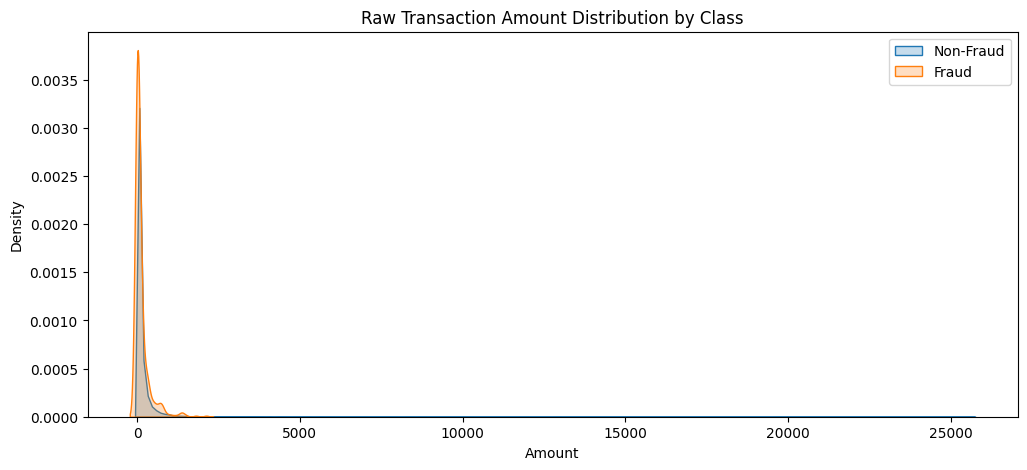

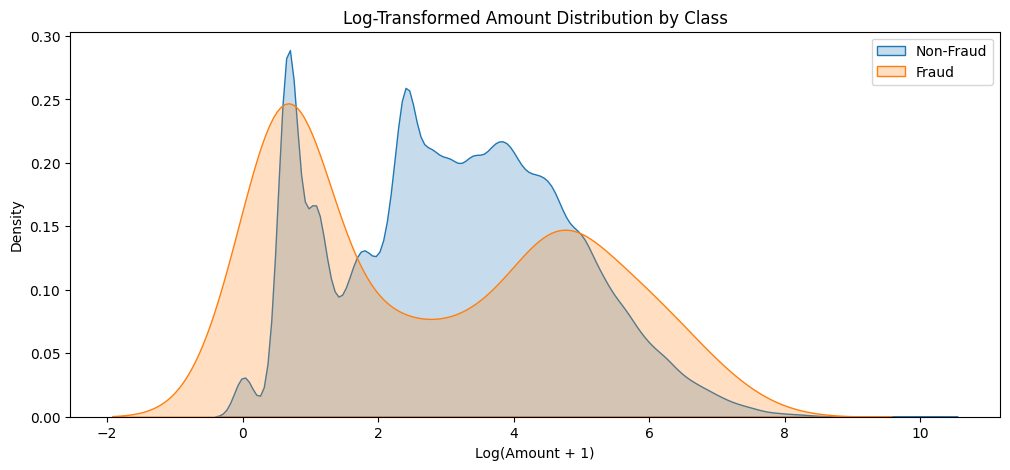

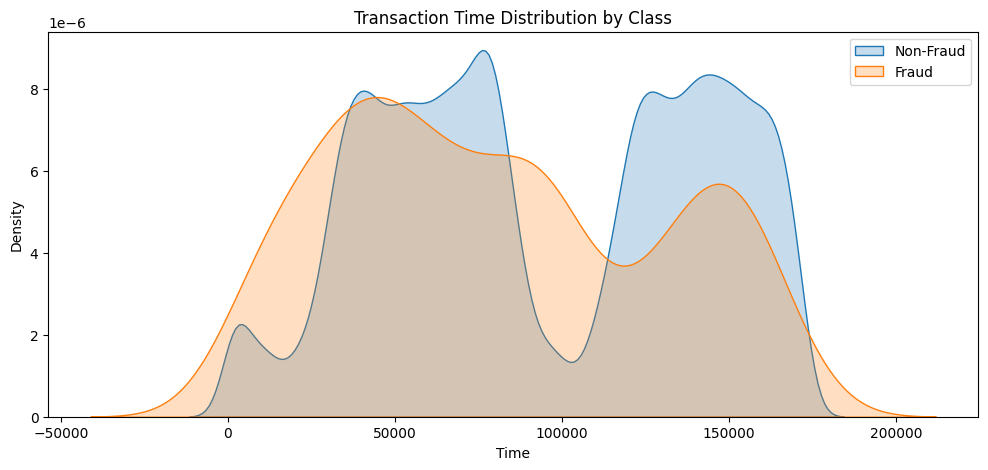

In [4]:
# =========================================================
# FRAUD VS NON-FRAUD DISTRIBUTION COMPARISON
# =========================================================

# Separate fraud and non-fraud transactions

fraud_transactions = df[df["Class"] == 1]
non_fraud_transactions = df[df["Class"] == 0]

# =========================================================
# RAW AMOUNT DISTRIBUTION COMPARISON
# =========================================================

plt.figure(figsize=(12, 5))

sns.kdeplot(
    non_fraud_transactions["Amount"],
    label="Non-Fraud",
    fill=True
)

sns.kdeplot(
    fraud_transactions["Amount"],
    label="Fraud",
    fill=True
)

plt.title("Raw Transaction Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Density")

plt.legend()

plt.show()

# =========================================================
# LOG-TRANSFORMED AMOUNT DISTRIBUTION COMPARISON
# =========================================================

plt.figure(figsize=(12, 5))

sns.kdeplot(
    np.log1p(non_fraud_transactions["Amount"]),
    label="Non-Fraud",
    fill=True
)

sns.kdeplot(
    np.log1p(fraud_transactions["Amount"]),
    label="Fraud",
    fill=True
)

plt.title("Log-Transformed Amount Distribution by Class")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Density")

plt.legend()

plt.show()

# =========================================================
# TIME DISTRIBUTION COMPARISON
# =========================================================

plt.figure(figsize=(12, 5))

sns.kdeplot(
    non_fraud_transactions["Time"],
    label="Non-Fraud",
    fill=True
)

sns.kdeplot(
    fraud_transactions["Time"],
    label="Fraud",
    fill=True
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.legend()

plt.show()

#### Correlation and Relationship Analysis with the target variable

Feature correlations with target variable:


Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


Top positive correlations with fraud:


V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


Top negative correlations with fraud:


V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

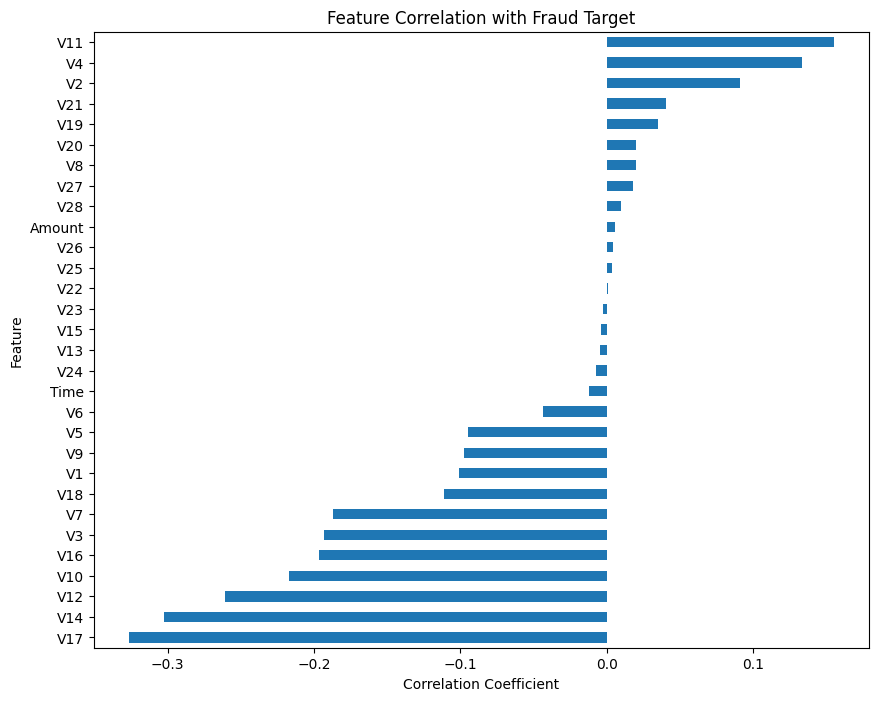

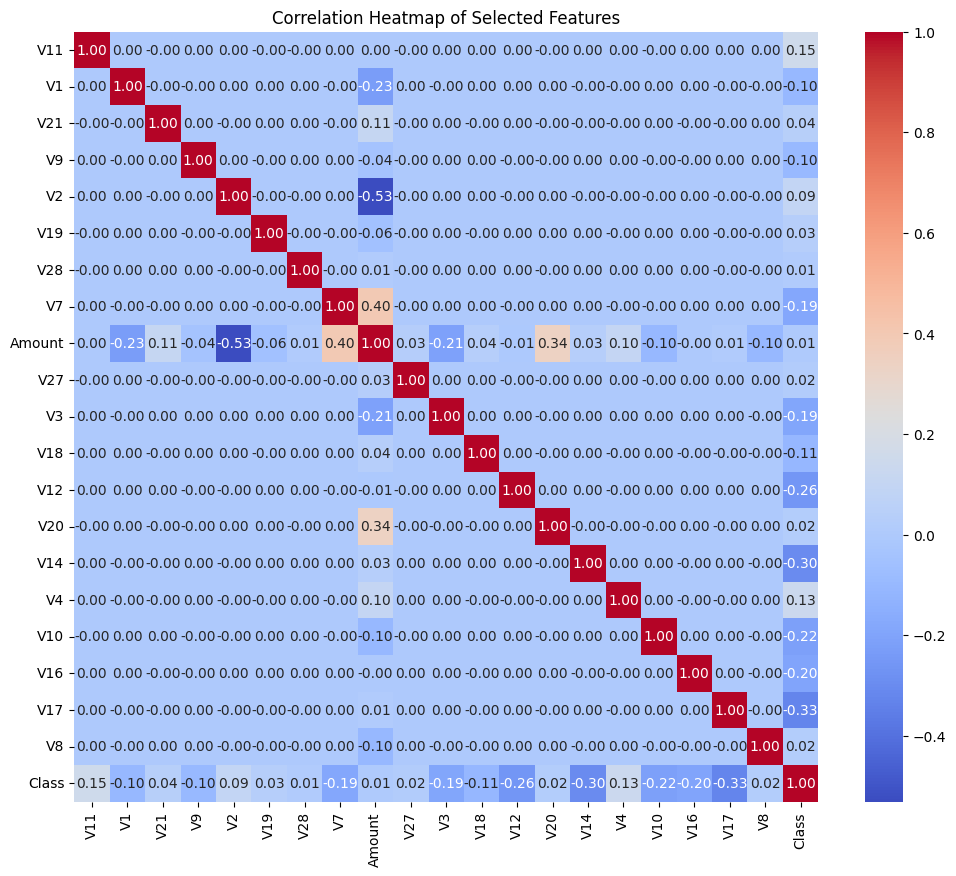

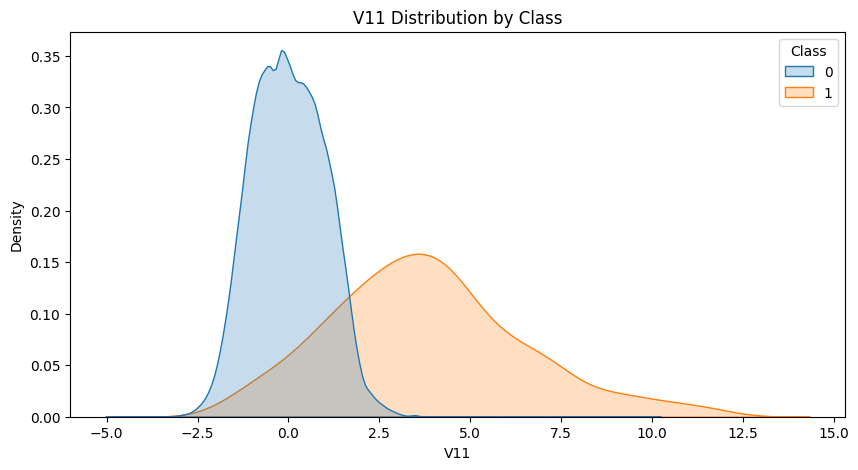

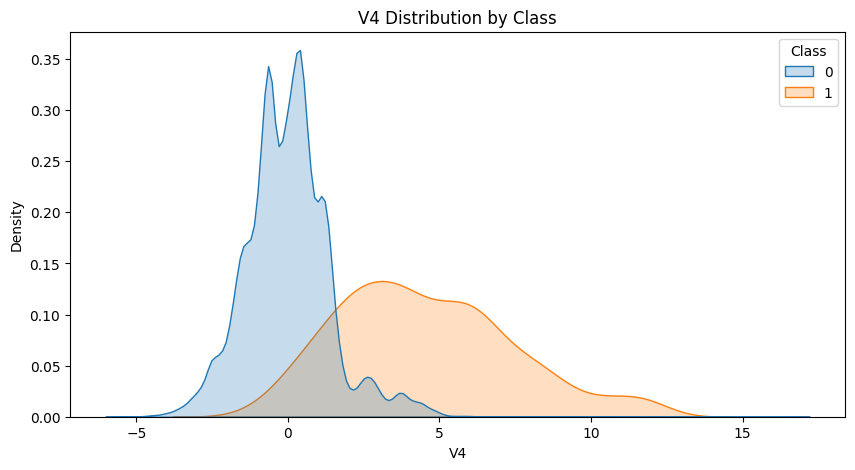

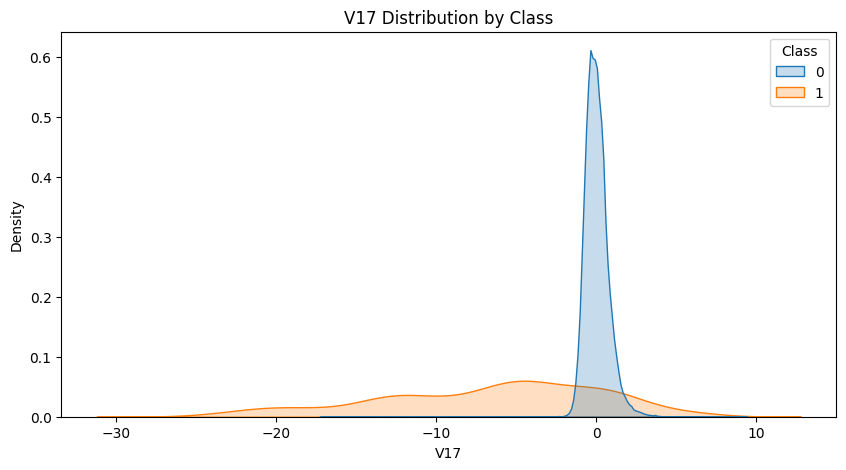

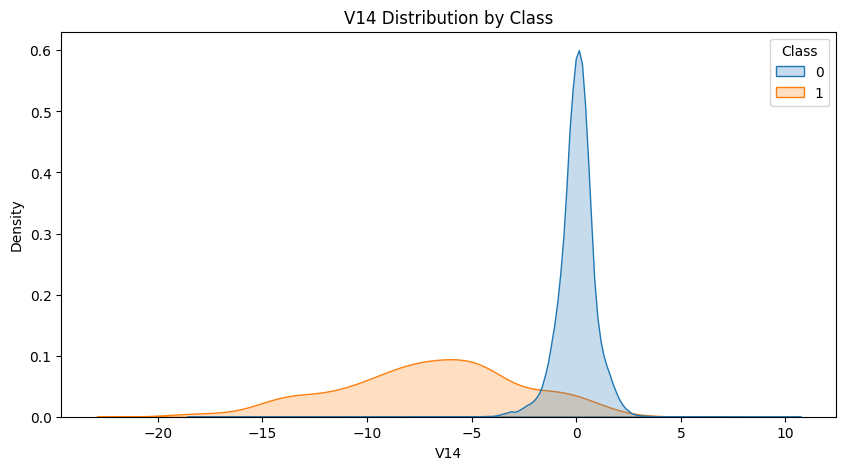


Potential leakage inspection:


Class    1.0
Name: Class, dtype: float64

In [5]:
# =========================================================
# BLOCK 6 — CORRELATION AND RELATIONSHIP ANALYSIS
# =========================================================

# Objective:
# Analyze feature relationships with the target variable and identify potentially useful predictive signals for fraud detection modeling.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# CORRELATION WITH TARGET VARIABLE
# =========================================================

# Compute correlations against target variable

target_correlations = (
    df.corr(numeric_only=True)["Class"]
    .sort_values(ascending=False)
)

print("Feature correlations with target variable:")
display(target_correlations)

# =========================================================
# TOP POSITIVE CORRELATIONS
# =========================================================

top_positive = (
    target_correlations
    .drop("Class")
    .head(10)
)

print("\nTop positive correlations with fraud:")
display(top_positive)

# =========================================================
# TOP NEGATIVE CORRELATIONS
# =========================================================

top_negative = (
    target_correlations
    .tail(10)
)

print("\nTop negative correlations with fraud:")
display(top_negative)

# =========================================================
# TARGET CORRELATION VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 8))

target_correlations.drop("Class").sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Fraud Target")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

# =========================================================
# HEATMAP OF MOST RELEVANT FEATURES
# =========================================================

# Select strongest positive and negative correlations

selected_features = list(
    top_positive.index
) + list(
    top_negative.index
)

selected_features = list(set(selected_features))

selected_features.append("Class")

correlation_subset = (
    df[selected_features]
    .corr()
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_subset,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Selected Features")

plt.show()

# =========================================================
# DISTRIBUTION COMPARISON OF TOP FEATURES
# =========================================================

# Visual comparison between fraud and non-fraud
# for strongest correlated variables

top_features_to_visualize = [
    top_positive.index[0],
    top_positive.index[1],
    top_negative.index[-1],
    top_negative.index[-2]
]

for feature in top_features_to_visualize:

    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False
    )

    plt.title(f"{feature} Distribution by Class")

    plt.show()

# =========================================================
# POSSIBLE DATA LEAKAGE INSPECTION
# =========================================================

# Extremely high correlations may indicate:
# - leakage
# - engineered artifacts
# - target contamination

high_correlation_features = target_correlations[
    abs(target_correlations) > 0.9
]

print("\nPotential leakage inspection:")
display(high_correlation_features)




In [ ]:
# =========================================================
# DISPLAY ALL ROWS OF THE CORRELATION TABLE
# =========================================================

#import pandas as pd

#pd.set_option('display.max_rows', None)

#display(correlation_table)

####  Exploratory Feature Engineering: light exploratory preprocessing experiments

Original Amount statistics:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Log-transformed Amount statistics:


count    284807.000000
mean          3.152188
std           1.656648
min           0.000000
25%           1.887070
50%           3.135494
75%           4.358822
max          10.153941
Name: Log_Amount, dtype: float64

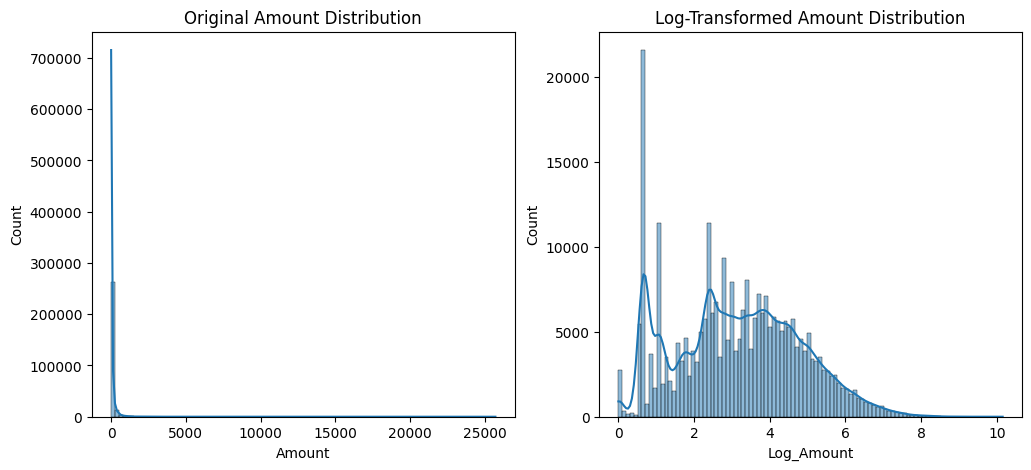

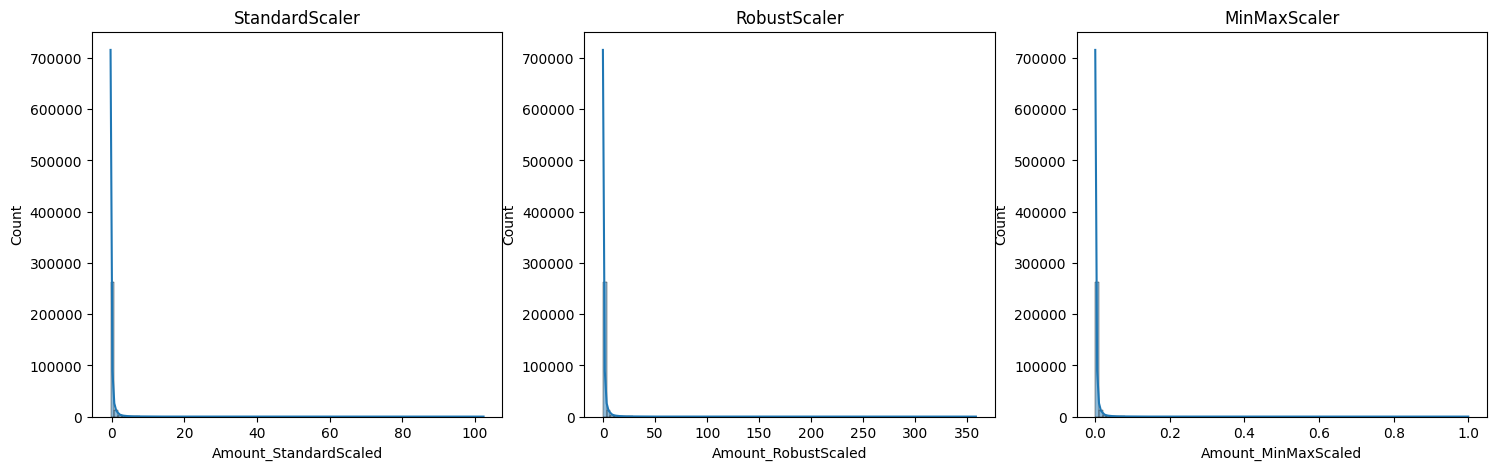

Scaling summary statistics:


,Amount,Log_Amount,Amount_StandardScaled,Amount_RobustScaled,Amount_MinMaxScaled
count,284807.000000,284807.000000,2.848070e+05,284807.000000,284807.000000
mean,88.349619,3.152188,2.913952e-17,0.927124,0.003439
std,250.120109,1.656648,1.000002e+00,3.495006,0.009736
min,0.000000,0.000000,-3.532294e-01,-0.307413,0.000000
25%,5.600000,1.887070,-3.308401e-01,-0.229162,0.000218
50%,22.000000,3.135494,-2.652715e-01,0.000000,0.000856
75%,77.165000,4.358822,-4.471707e-02,0.770838,0.003004
max,25691.160000,10.153941,1.023622e+02,358.683155,1.000000


Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Undersampled class distribution:
Class
1    492
0    492
Name: count, dtype: int64


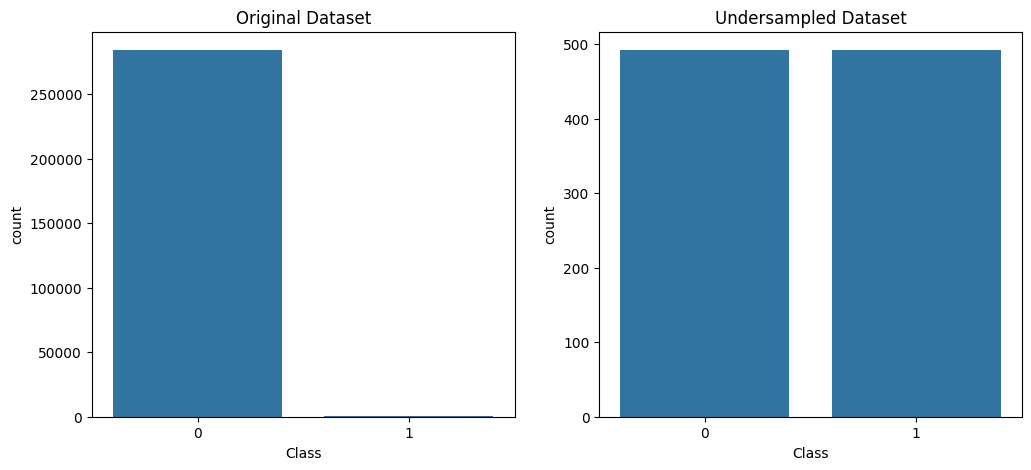

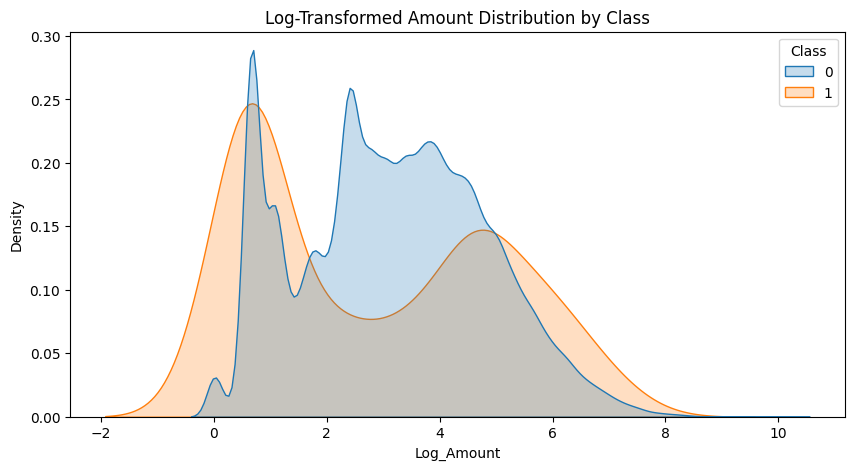


Exploratory feature engineering completed.


In [4]:
# =========================================================
# BLOCK 7 — EXPLORATORY FEATURE ENGINEERING
# =========================================================

# Objective: Perform exploratory preprocessing experiments to evaluate potential transformations and scaling strategies for fraud detection modeling.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler
)

from sklearn.utils import resample

# =========================================================
# CREATE WORKING COPY
# =========================================================

df_fe = df.copy()

# =========================================================
# LOG TRANSFORMATION OF AMOUNT
# =========================================================

df_fe["Log_Amount"] = np.log1p(df_fe["Amount"])

print("Original Amount statistics:")
display(df_fe["Amount"].describe())

print("\nLog-transformed Amount statistics:")
display(df_fe["Log_Amount"].describe())

# =========================================================
# VISUALIZE ORIGINAL VS LOG-TRANSFORMED AMOUNT
# =========================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.histplot(
    df_fe["Amount"],
    bins=100,
    kde=True
)

plt.title("Original Amount Distribution")

plt.subplot(1, 2, 2)

sns.histplot(
    df_fe["Log_Amount"],
    bins=100,
    kde=True
)

plt.title("Log-Transformed Amount Distribution")

plt.show()

# =========================================================
# SCALING EXPERIMENTS
# =========================================================

# Apply different scaling methods

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()

df_fe["Amount_StandardScaled"] = (
    standard_scaler.fit_transform(
        df_fe[["Amount"]]
    )
)

df_fe["Amount_RobustScaled"] = (
    robust_scaler.fit_transform(
        df_fe[["Amount"]]
    )
)

df_fe["Amount_MinMaxScaled"] = (
    minmax_scaler.fit_transform(
        df_fe[["Amount"]]
    )
)

# =========================================================
# VISUALIZE SCALING METHODS
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    df_fe["Amount_StandardScaled"],
    bins=100,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("StandardScaler")

sns.histplot(
    df_fe["Amount_RobustScaled"],
    bins=100,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("RobustScaler")

sns.histplot(
    df_fe["Amount_MinMaxScaled"],
    bins=100,
    kde=True,
    ax=axes[2]
)

axes[2].set_title("MinMaxScaler")

plt.show()

# =========================================================
# SCALING SUMMARY STATISTICS
# =========================================================

scaling_summary = df_fe[
    [
        "Amount",
        "Log_Amount",
        "Amount_StandardScaled",
        "Amount_RobustScaled",
        "Amount_MinMaxScaled"
    ]
].describe()

print("Scaling summary statistics:")
display(scaling_summary)

# =========================================================
# CLASS DISTRIBUTION BEFORE RESAMPLING
# =========================================================

print("Original class distribution:")
print(df_fe["Class"].value_counts())

# =========================================================
# UNDERSAMPLING EXPERIMENT
# =========================================================

fraud_df = df_fe[df_fe["Class"] == 1]
non_fraud_df = df_fe[df_fe["Class"] == 0]

non_fraud_downsampled = resample(
    non_fraud_df,
    replace=False,
    n_samples=len(fraud_df),
    random_state=42
)

undersampled_df = pd.concat([
    fraud_df,
    non_fraud_downsampled
])

print("\nUndersampled class distribution:")
print(undersampled_df["Class"].value_counts())

# =========================================================
# VISUALIZE CLASS DISTRIBUTIONS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    x="Class",
    data=df_fe,
    ax=axes[0]
)

axes[0].set_title("Original Dataset")

sns.countplot(
    x="Class",
    data=undersampled_df,
    ax=axes[1]
)

axes[1].set_title("Undersampled Dataset")

plt.show()

# =========================================================
# FRAUD VS NON-FRAUD DISTRIBUTION AFTER TRANSFORMATION
# =========================================================

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df_fe,
    x="Log_Amount",
    hue="Class",
    fill=True,
    common_norm=False
)

plt.title("Log-Transformed Amount Distribution by Class")

plt.show()

# =========================================================
# FEATURE ENGINEERING SUMMARY
# =========================================================

print("\nExploratory feature engineering completed.")

#### Baseline Modeling: initial exploratory models

Training set shape: (227845, 30)
Test set shape: (56962, 30)


C:\Users\nmeri\anaconda3\envs\Curso_MachineLearning\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LOGISTIC REGRESSION RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Confusion Matrix:
[[55424  1440]
 [    8    90]]

Metrics:
Accuracy: 0.9745795442575752
Precision: 0.058823529411764705
Recall: 0.9183673469387755
F1-score: 0.11056511056511056
ROC-AUC: 0.9718396309705649

RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56861     3]
 [   25 

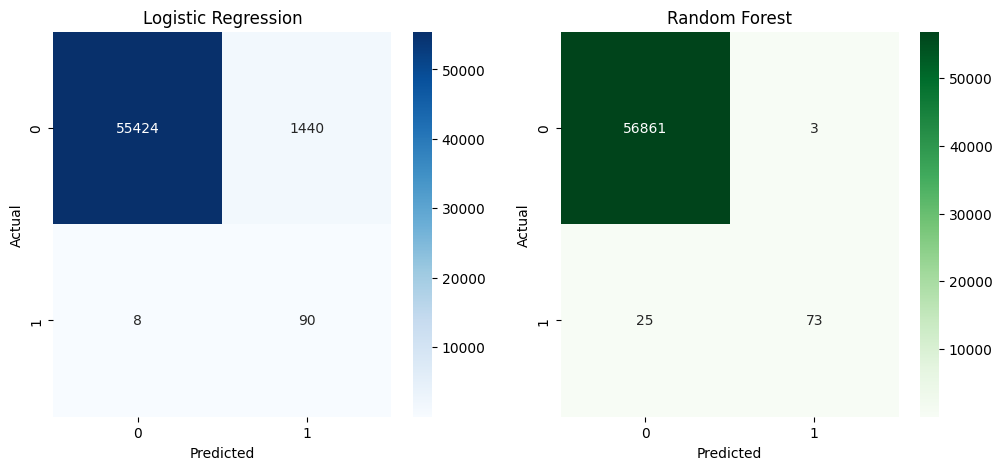


Top Random Forest Feature Importances:


,Feature,Importance
14,V14,0.179857
10,V10,0.115442
12,V12,0.096206
4,V4,0.095646
17,V17,0.095113
3,V3,0.068669
11,V11,0.056112
16,V16,0.040303
2,V2,0.036265
9,V9,0.026888


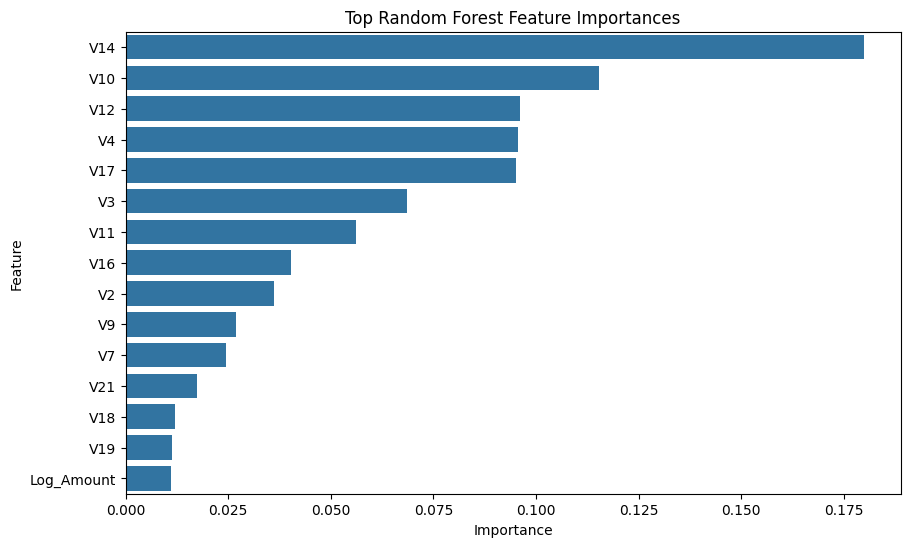


Baseline modeling completed.


In [5]:
# =========================================================
# BLOCK 8 — BASELINE MODELING
# =========================================================

# Objective: Train initial baseline models to evaluate fraud detection behavior and establish preliminary performance benchmarks.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# PREPARE FEATURES AND TARGET
# =========================================================

# Use log-transformed Amount

df_model = df.copy()

df_model["Log_Amount"] = np.log1p(df_model["Amount"])

# Remove original Amount column

df_model = df_model.drop(columns=["Amount"])

# =========================================================
# DEFINE FEATURES AND TARGET
# =========================================================

X = df_model.drop(columns=["Class"])
y = df_model["Class"]

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# =========================================================
# BASELINE LOGISTIC REGRESSION
# =========================================================

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

# =========================================================
# LOGISTIC REGRESSION PREDICTIONS
# =========================================================

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# =========================================================
# LOGISTIC REGRESSION METRICS
# =========================================================

print("\n=================================================")
print("LOGISTIC REGRESSION RESULTS")
print("=================================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nMetrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

# =========================================================
# RANDOM FOREST BASELINE
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =========================================================
# RANDOM FOREST PREDICTIONS
# =========================================================

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# =========================================================
# RANDOM FOREST METRICS
# =========================================================

print("\n=================================================")
print("RANDOM FOREST RESULTS")
print("=================================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nMetrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# =========================================================
# CONFUSION MATRIX VISUALIZATION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()

# =========================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# =========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Random Forest Feature Importances:")
display(feature_importance.head(15))

# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")

plt.show()

# =========================================================
# BASELINE MODELING SUMMARY
# =========================================================

print("\nBaseline modeling completed.")

#### Model Evaluation and Metric Comparison

PRECISION-RECALL AUC
Logistic Regression PR-AUC: 0.710028
Random Forest PR-AUC: 0.854335


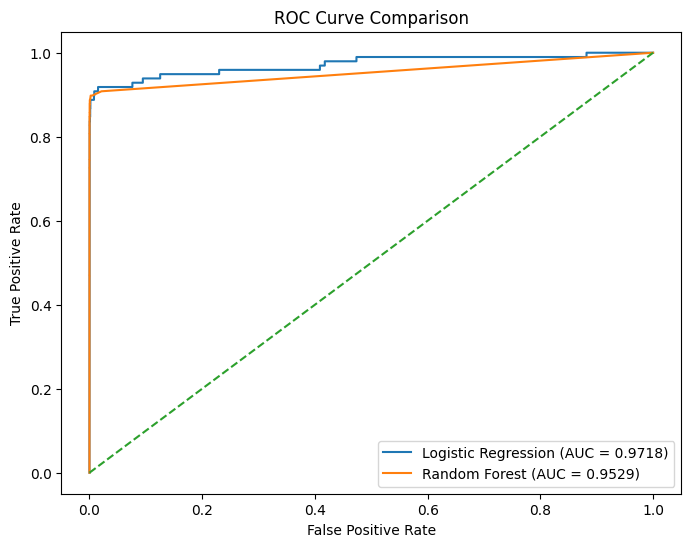

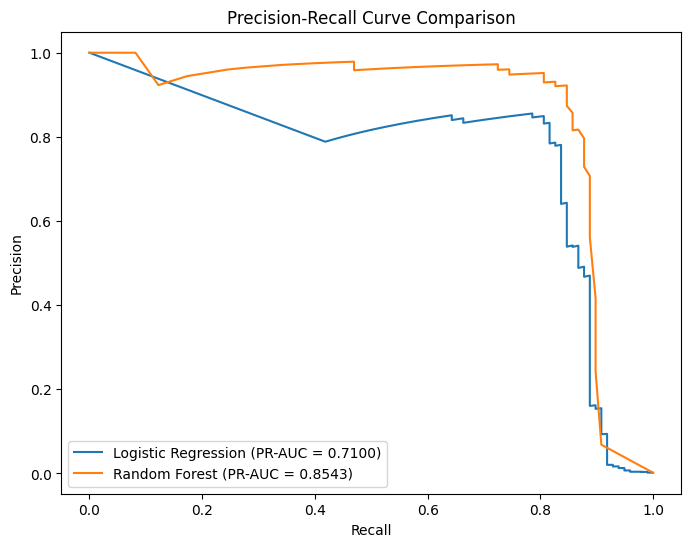


FALSE POSITIVE / FALSE NEGATIVE ANALYSIS

Logistic Regression:
False Positives: 1440
False Negatives: 8

Random Forest:
False Positives: 3
False Negatives: 25

False Positive Rates:
Logistic Regression FPR: 0.025324
Random Forest FPR: 0.000053

False Negative Rates:
Logistic Regression FNR: 0.081633
Random Forest FNR: 0.255102

MODEL METRIC COMPARISON


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.974580,0.999508
1,Precision,0.058824,0.960526
2,Recall,0.918367,0.744898
3,F1-score,0.110565,0.839080
4,ROC-AUC,0.971840,0.952910
5,PR-AUC,0.710028,0.854335
6,False Positive Rate,0.025324,0.000053
7,False Negative Rate,0.081633,0.255102



BUSINESS INTERPRETATION

High Recall:
- Detects more fraud cases
- Reduces missed fraud
- May increase false positives

High Precision:
- Produces fewer false fraud alerts
- Improves analyst efficiency
- May miss some fraud cases

PR-AUC:
- More informative than ROC-AUC for highly imbalanced datasets

False Positives:
- Legitimate users incorrectly flagged as fraud

False Negatives:
- Fraud cases missed by the model



In [6]:
# =========================================================
# BLOCK 9 — MODEL EVALUATION AND METRIC COMPARISON
# =========================================================

# Objective: Perform deeper evaluation analysis for baseline fraud detection models, focusing on:
# - precision vs recall tradeoffs
# - ROC-AUC vs PR-AUC
# - confusion matrix interpretation
# - false positive / false negative behavior
# - threshold-independent evaluation

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    confusion_matrix
)

# =========================================================
# PRECISION-RECALL CURVES
# =========================================================

lr_precision, lr_recall, lr_thresholds = precision_recall_curve(
    y_test,
    y_prob_lr
)

rf_precision, rf_recall, rf_thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

# =========================================================
# PR-AUC SCORES
# =========================================================

lr_pr_auc = average_precision_score(
    y_test,
    y_prob_lr
)

rf_pr_auc = average_precision_score(
    y_test,
    y_prob_rf
)

print("=================================================")
print("PRECISION-RECALL AUC")
print("=================================================")

print(f"Logistic Regression PR-AUC: {lr_pr_auc:.6f}")
print(f"Random Forest PR-AUC: {rf_pr_auc:.6f}")

# =========================================================
# ROC CURVES
# =========================================================

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    y_prob_lr
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    y_prob_rf
)

lr_roc_auc = auc(lr_fpr, lr_tpr)
rf_roc_auc = auc(rf_fpr, rf_tpr)

# =========================================================
# ROC CURVE VISUALIZATION
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# PRECISION-RECALL CURVE VISUALIZATION
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (PR-AUC = {lr_pr_auc:.4f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (PR-AUC = {rf_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# =========================================================

# Logistic Regression confusion matrix

lr_cm = confusion_matrix(
    y_test,
    y_pred_lr
)

# Random Forest confusion matrix

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

# =========================================================
# EXTRACT CONFUSION MATRIX COMPONENTS
# =========================================================

lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

# =========================================================
# DISPLAY FALSE POSITIVE ANALYSIS
# =========================================================

print("\n=================================================")
print("FALSE POSITIVE / FALSE NEGATIVE ANALYSIS")
print("=================================================")

print("\nLogistic Regression:")
print(f"False Positives: {lr_fp}")
print(f"False Negatives: {lr_fn}")

print("\nRandom Forest:")
print(f"False Positives: {rf_fp}")
print(f"False Negatives: {rf_fn}")

# =========================================================
# FALSE POSITIVE RATES
# =========================================================

lr_fpr_value = lr_fp / (lr_fp + lr_tn)
rf_fpr_value = rf_fp / (rf_fp + rf_tn)

print("\nFalse Positive Rates:")

print(f"Logistic Regression FPR: {lr_fpr_value:.6f}")
print(f"Random Forest FPR: {rf_fpr_value:.6f}")

# =========================================================
# FALSE NEGATIVE RATES
# =========================================================

lr_fnr_value = lr_fn / (lr_fn + lr_tp)
rf_fnr_value = rf_fn / (rf_fn + rf_tp)

print("\nFalse Negative Rates:")

print(f"Logistic Regression FNR: {lr_fnr_value:.6f}")
print(f"Random Forest FNR: {rf_fnr_value:.6f}")

# =========================================================
# METRIC COMPARISON TABLE
# =========================================================

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "False Negative Rate"
    ],

    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr),
        lr_pr_auc,
        lr_fpr_value,
        lr_fnr_value
    ],

    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf),
        rf_pr_auc,
        rf_fpr_value,
        rf_fnr_value
    ]
})

print("\n=================================================")
print("MODEL METRIC COMPARISON")
print("=================================================")

display(comparison_df)

# =========================================================
# BUSINESS INTERPRETATION SECTION
# =========================================================

print("\n=================================================")
print("BUSINESS INTERPRETATION")
print("=================================================")

print("""
High Recall:
- Detects more fraud cases
- Reduces missed fraud
- May increase false positives

High Precision:
- Produces fewer false fraud alerts
- Improves analyst efficiency
- May miss some fraud cases

PR-AUC:
- More informative than ROC-AUC for highly imbalanced datasets

False Positives:
- Legitimate users incorrectly flagged as fraud

False Negatives:
- Fraud cases missed by the model
""")



#### Feature Importance and Model Insights

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
14,V14,0.179857
10,V10,0.115442
12,V12,0.096206
4,V4,0.095646
17,V17,0.095113
3,V3,0.068669
11,V11,0.056112
16,V16,0.040303
2,V2,0.036265
9,V9,0.026888


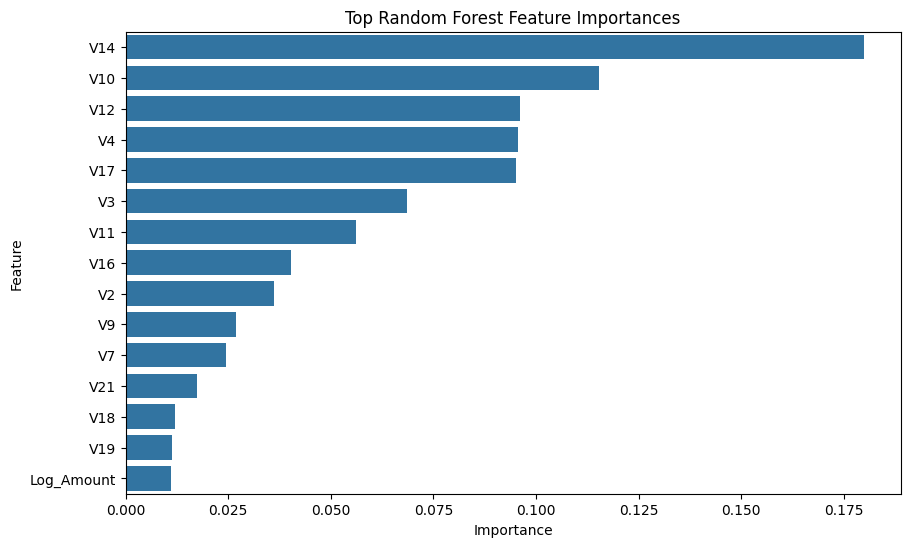


PERMUTATION IMPORTANCE


,Feature,Permutation_Importance
12,V12,0.674896
14,V14,0.594588
11,V11,0.322023
3,V3,0.308014
4,V4,0.295783
10,V10,0.217188
9,V9,0.026977
17,V17,0.016943
16,V16,0.013765
26,V26,0.011042


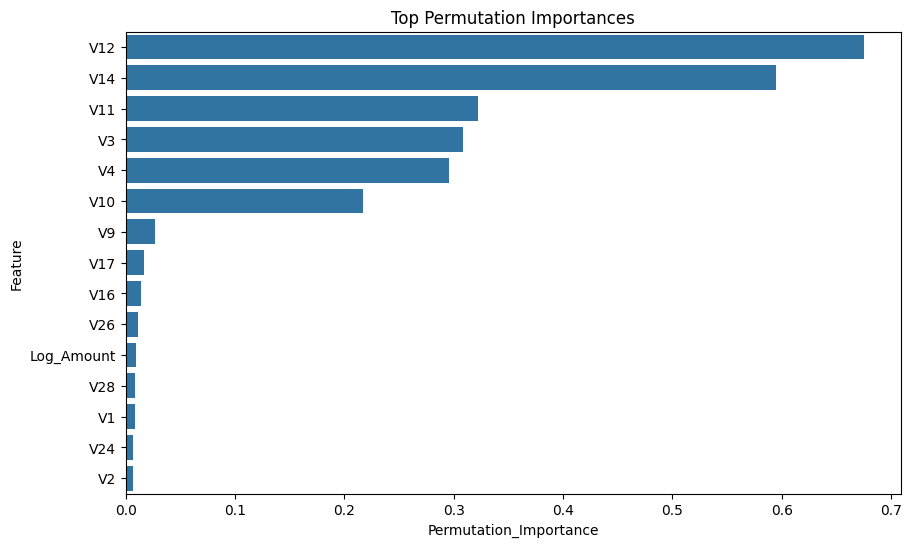


IMPORTANCE VS CORRELATION


,Feature,Importance,Correlation_With_Fraud
0,V14,0.179857,-0.302544
1,V10,0.115442,-0.216883
2,V12,0.096206,-0.260593
3,V4,0.095646,0.133447
4,V17,0.095113,-0.326481
5,V3,0.068669,-0.192961
6,V11,0.056112,0.154876
7,V16,0.040303,-0.196539
8,V2,0.036265,0.091289
9,V9,0.026888,-0.097733


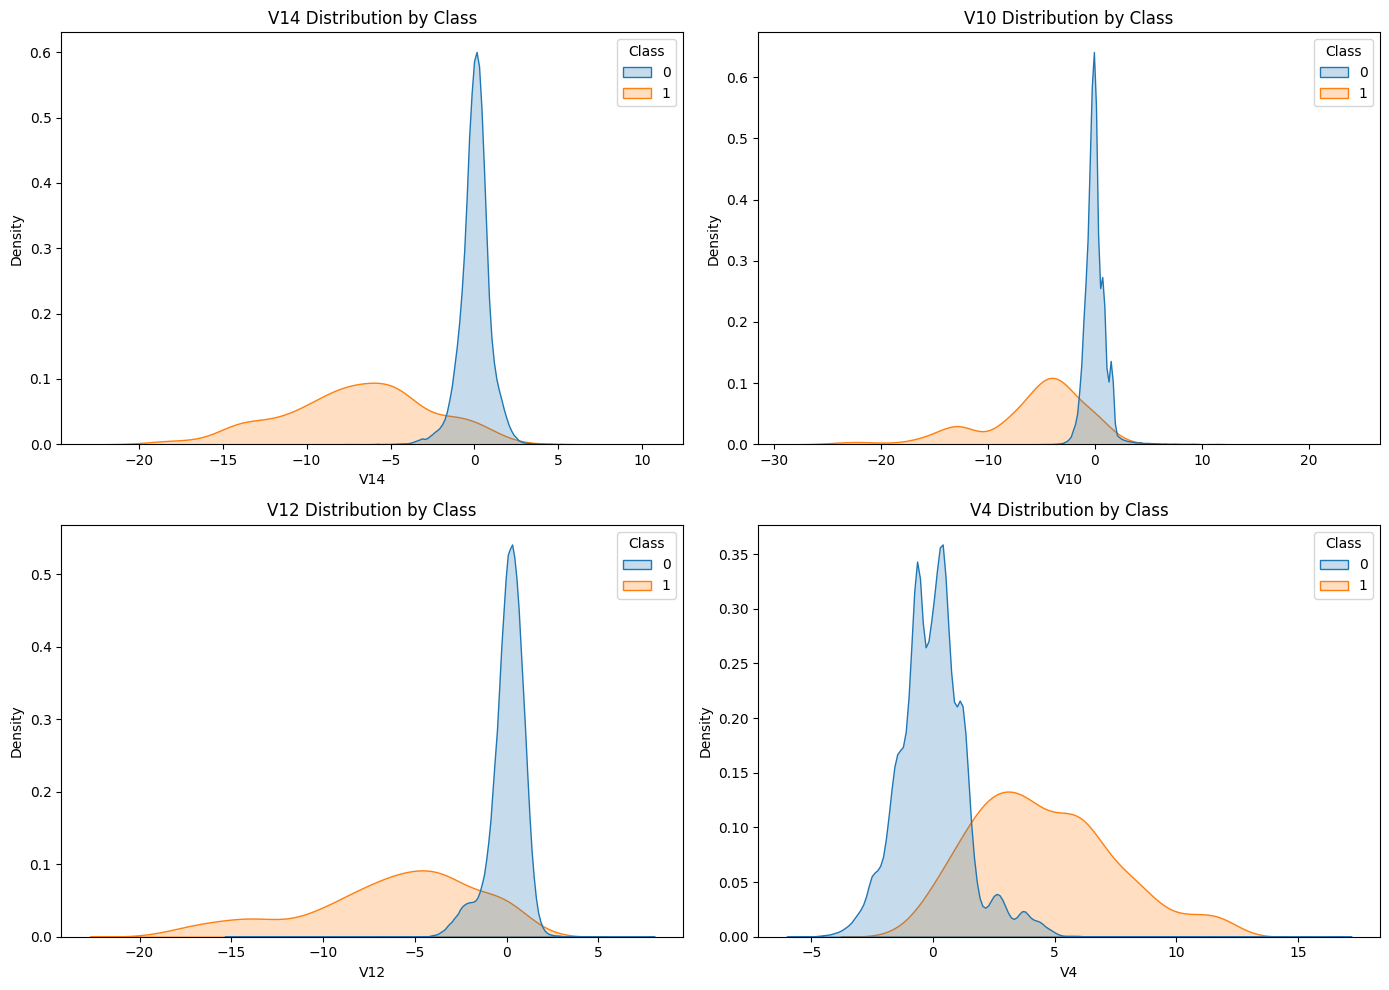


FEATURE CONSISTENCY ANALYSIS
Common important features:
{'V4', 'V3', 'V14', 'V17', 'V11', 'V12', 'V16', 'V10'}

LOW IMPORTANCE FEATURES


,Feature,Importance
13,V13,0.008693
5,V5,0.007700
28,V28,0.007106
15,V15,0.006964
22,V22,0.005800
6,V6,0.005656
23,V23,0.005280
0,Time,0.005269
25,V25,0.005048
24,V24,0.004325



MODEL INSIGHT SUMMARY

Key observations:
- Some latent PCA variables consistently dominate fraud detection.
- Strong agreement exists between:
    correlation analysis,
    feature importance,
    and class-separation behavior.
- Fraud detection appears driven by a relatively small
  subset of highly informative latent variables.
- Nonlinear interactions likely play an important role.


Feature importance and model insight analysis completed.


In [7]:
# =========================================================
# BLOCK 10 — FEATURE IMPORTANCE AND MODEL INSIGHTS
# =========================================================

# Objective: Analyze feature importance, inspect the strongest fraud indicators, interpret model behavior, and 
# identify the most informative latent variables.

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance

# =========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================================================

rf_importance_df = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("=================================================")
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=================================================")

display(rf_importance_df.head(15))

# =========================================================
# VISUALIZE TOP FEATURE IMPORTANCE
# =========================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")

plt.show()

# =========================================================
# PERMUTATION IMPORTANCE ANALYSIS
# =========================================================

# Permutation importance measures how much model
# performance decreases when a feature is shuffled.

perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1"
)

perm_importance_df = pd.DataFrame({

    "Feature": X.columns,
    "Permutation_Importance": perm_importance.importances_mean

})

perm_importance_df = perm_importance_df.sort_values(
    by="Permutation_Importance",
    ascending=False
)

print("\n=================================================")
print("PERMUTATION IMPORTANCE")
print("=================================================")

display(perm_importance_df.head(15))

# =========================================================
# VISUALIZE PERMUTATION IMPORTANCE
# =========================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=perm_importance_df.head(15),
    x="Permutation_Importance",
    y="Feature"
)

plt.title("Top Permutation Importances")

plt.show()

# =========================================================
# COMPARE IMPORTANCE VS CORRELATION
# =========================================================

correlation_df = pd.DataFrame({

    "Feature": X.columns,
    "Correlation_With_Fraud": X.corrwith(y).values

})

comparison_df = rf_importance_df.merge(
    correlation_df,
    on="Feature"
)

comparison_df = comparison_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n=================================================")
print("IMPORTANCE VS CORRELATION")
print("=================================================")

display(
    comparison_df.head(15)
)

# =========================================================
# VISUALIZE TOP FRAUD INDICATORS
# =========================================================

top_features = (
    rf_importance_df["Feature"]
    .head(4)
    .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, feature in enumerate(top_features):

    sns.kdeplot(
        data=df_model,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} Distribution by Class"
    )

plt.tight_layout()

plt.show()

# =========================================================
# FEATURE IMPORTANCE CONSISTENCY CHECK
# =========================================================

top_rf_features = set(
    rf_importance_df.head(10)["Feature"]
)

top_corr_features = set(
    comparison_df.sort_values(
        by="Correlation_With_Fraud",
        key=abs,
        ascending=False
    ).head(10)["Feature"]
)

common_features = (
    top_rf_features
    .intersection(top_corr_features)
)

print("\n=================================================")
print("FEATURE CONSISTENCY ANALYSIS")
print("=================================================")

print("Common important features:")
print(common_features)

# =========================================================
# LOW-IMPORTANCE FEATURES
# =========================================================

low_importance_df = rf_importance_df.tail(10)

print("\n=================================================")
print("LOW IMPORTANCE FEATURES")
print("=================================================")

display(low_importance_df)

# =========================================================
# MODEL INSIGHT SUMMARY
# =========================================================

print("\n=================================================")
print("MODEL INSIGHT SUMMARY")
print("=================================================")

print("""
Key observations:
- Some latent PCA variables consistently dominate fraud detection.
- Strong agreement exists between:
    correlation analysis,
    feature importance,
    and class-separation behavior.
- Fraud detection appears driven by a relatively small
  subset of highly informative latent variables.
- Nonlinear interactions likely play an important role.
""")

print("\nFeature importance and model insight analysis completed.")

In [2]:
# =========================================================
# BLOCK 11 — PHASE 1 CONCLUSIONS
# =========================================================

# Objective:
# Consolidate the main findings obtained during
# Phase 1 exploratory analysis and establish the
# transition toward production-oriented pipeline
# development.

# =========================================================
# PHASE 1 — FINAL SUMMARY
# =========================================================

print("=================================================")
print("PHASE 1 — FINAL CONCLUSIONS")
print("=================================================")

# =========================================================
# DATA UNDERSTANDING SUMMARY
# =========================================================

print("\n1. DATA UNDERSTANDING")

print("""
- The dataset contains highly imbalanced fraud data:
    Non-fraud transactions: 284,315
    Fraud transactions: 492

- Fraud ratio:
    approximately 0.1727%

- Fraud detection therefore represents a severe
  class imbalance problem.

- The dataset contains anonymized PCA-transformed
  variables (V1–V28), meaning:
    fraud signal exists in latent behavioral dimensions.

- Transaction Amount and Time variables remain
  interpretable original features.
""")

# =========================================================
# DATA QUALITY SUMMARY
# =========================================================

print("\n2. DATA QUALITY ASSESSMENT")

print("""
- No missing values detected.
- No infinite values detected.

- Duplicate rows detected:
    1,081 rows

- Large numbers of outliers exist across multiple features.
- Heavy skewness observed especially in:
    Amount,
    V28,
    V8,
    V23.

- Skewness and outliers appear partially expected in:
    transactional financial behavior.

- Extreme values should be handled carefully rather
  than automatically removed because:
    some fraud signal may exist within extreme regions.
""")

# =========================================================
# EDA SUMMARY
# =========================================================

print("\n3. EXPLORATORY DATA ANALYSIS")

print("""
- Fraud and non-fraud transactions exhibit
  partially separable behavioral structure.

- Amount distribution is highly right-skewed.

- Fraud transactions tend to occupy abnormal
  latent PCA regions.

- Zero-amount transactions and high-value
  transactions contain both:
    legitimate behavior,
    and fraud behavior.

- Fraud does not appear to follow:
    a single simple transactional pattern.
""")

# =========================================================
# FEATURE ENGINEERING SUMMARY
# =========================================================

print("\n4. FEATURE ENGINEERING INSIGHTS")

print("""
- Log transformation substantially stabilized
  the Amount distribution.

- RobustScaler appeared more resistant to
  outlier distortion than:
    StandardScaler,
    and MinMaxScaler.

- Severe imbalance experiments demonstrated:
    undersampling improves balance
    but introduces major information loss.

- Future preprocessing pipelines should evaluate:
    imbalance-aware strategies,
    scaling consistency,
    and transformation stability.
""")

# =========================================================
# CORRELATION AND FEATURE INSIGHTS
# =========================================================

print("\n5. FEATURE RELATIONSHIP INSIGHTS")

print("""
- Multiple latent variables consistently emerged
  as strong fraud indicators:
    V14,
    V12,
    V10,
    V17,
    V4,
    V11.

- Strong agreement exists across:
    correlation analysis,
    Random Forest importance,
    permutation importance,
    and KDE separation analysis.

- Fraud signal appears:
    stable,
    nonlinear,
    and interaction-driven.

- Amount and Time alone provide limited
  predictive power relative to latent dimensions.
""")

# =========================================================
# MODELING INSIGHTS
# =========================================================

print("\n6. BASELINE MODELING INSIGHTS")

print("""
- Logistic Regression achieved:
    very high recall,
    but extremely poor precision.

- Random Forest achieved:
    very high precision,
    dramatically lower false positives,
    and stronger operational balance.

- Fraud detection performance depends heavily on:
    metric selection,
    threshold behavior,
    and imbalance-aware evaluation.

- PR-AUC proved more informative than:
    accuracy alone,
    and ROC-AUC alone.

- Fraud detection appears strongly nonlinear,
  suggesting:
    advanced ensemble models may perform well.
""")

# =========================================================
# OPERATIONAL FRAUD-DETECTION INSIGHTS
# =========================================================

print("\n7. OPERATIONAL FRAUD-DETECTION INSIGHTS")

print("""
- Models with high recall detect more fraud cases
  but may generate large numbers of false alerts.

- Models with high precision produce more reliable
  fraud alerts but may miss some fraudulent activity.

- Fraud detection therefore requires balancing:
    fraud capture,
    false alerts,
    customer experience,
    and operational workload.

- Future phases will likely require threshold tuning
  to optimize this balance for production scenarios.
""")

# =========================================================
# TRANSITION TO PRODUCTION PIPELINE
# =========================================================

print("\n8. TRANSITION TO PRODUCTION PIPELINE")

print("""
Phase 1 established:
- reliable exploratory understanding,
- stable fraud indicators,
- preprocessing direction,
- baseline model behavior,
- and evaluation methodology.

The next phases will focus on:
- scalable preprocessing pipelines,
- production-oriented feature engineering,
- advanced model training,
- threshold optimization,
- explainability frameworks,
- and deployment-oriented architecture.

Future implementation may transition toward:
- PySpark-based scalable pipelines,
- distributed preprocessing,
- modular ML architecture,
- experiment tracking,
- and production monitoring systems.
""")

# =========================================================
# FINAL PHASE 1 SUMMARY
# =========================================================

print("\n=================================================")
print("PHASE 1 COMPLETED")
print("=================================================")

print("""
Phase 1 successfully established:
- dataset understanding,
- fraud behavior characterization,
- preprocessing foundations,
- baseline modeling benchmarks,
- evaluation methodology,
- and interpretable fraud indicators.

The project now has:
- a strong analytical foundation,
- reproducible exploratory workflow,
- and clear direction for scalable
  production-oriented development.
""")

PHASE 1 — FINAL CONCLUSIONS

1. DATA UNDERSTANDING

- The dataset contains highly imbalanced fraud data:
    Non-fraud transactions: 284,315
    Fraud transactions: 492

- Fraud ratio:
    approximately 0.1727%

- Fraud detection therefore represents a severe
  class imbalance problem.

- The dataset contains anonymized PCA-transformed
  variables (V1–V28), meaning:
    fraud signal exists in latent behavioral dimensions.

- Transaction Amount and Time variables remain
  interpretable original features.


2. DATA QUALITY ASSESSMENT

- No missing values detected.
- No infinite values detected.

- Duplicate rows detected:
    1,081 rows

- Large numbers of outliers exist across multiple features.
- Heavy skewness observed especially in:
    Amount,
    V28,
    V8,
    V23.

- Skewness and outliers appear partially expected in:
    transactional financial behavior.

- Extreme values should be handled carefully rather
  than automatically removed because:
    some fraud signal may exist w